# Round 011 — T3 opportunistic insider buying

ตัวเลขทั้งหมดอ่านจาก `results.csv` ที่ `run.py` ของ round นี้เขียนไว้ · ช่วงตัดสิน ก.ค. 2017 – มิ.ย. 2023 · ⚠️ survivorship: ราคาของหุ้นที่ออกจากตลาดไปแล้วหายบางส่วน → ผลอาจดูดีเกินจริง · held-out (ตั้งแต่ ก.ค. 2023) ไม่ถูกใช้

In [1]:
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
from IPython.display import Image, Markdown, display
from lib import report
report.banner()
r = pd.read_csv("../rounds/round_011/results.csv")
cols = [c for c in ["trial_id","dec_sharpe","dec_sharpe_ew","dec_sharpe_spy","dec_cagr","dec_cagr_ew","dec_maxdd","dec_maxdd_ew",
        "S1_10","S1_25","S2_share","DSR","S6_avg_n","S6_min_n","info_sharpe","info_sharpe_ew"] if c in r.columns]
pd.set_option("display.width", 250); pd.set_option("display.max_rows", 200)
display(r[cols].round(3))
ok = lambda c: r[c].astype(str).str.lower().eq("true")
print("ผู้เข้ารอบ (S1+S2+S3+S6):", list(r[ok("S1") & ok("S2") & ok("S3") & ok("S6")].trial_id))


> ⚠️ **คำเตือน survivorship bias (แสดงในทุก notebook)**
> รายชื่อสมาชิกมาจาก fja05680/sp500 (point-in-time) แต่ **ราคามาจาก yfinance ซึ่งเก็บเฉพาะหุ้นที่ยังซื้อขายอยู่**
> หุ้นที่ถูกซื้อกิจการ/ล้มละลาย/เปลี่ยนชื่อจำนวนหนึ่งจึงไม่มีราคา และหลุดออกจาก backtest
> ผลตอบแทนที่คำนวณได้จึงมีแนวโน้ม **สูงกว่าความจริง** (หุ้นที่ "ตาย" ไปมักเป็นหุ้นที่ผลตอบแทนแย่)
> สัดส่วนที่ขาดหายวัดไว้ใน `v0_data_audit.ipynb`

> ⚠️ **ข้อจำกัดของ held-out**: held-out = rebalance มิ.ย. 2023, 2024, 2025 (3 รอบเต็ม) + มิ.ย. 2026 ที่ถือได้แค่ ~3 เดือน
> (รอบ 2026 เป็นข้อมูลประกอบ ไม่นับตัดสิน) — มีแค่ 2–3 รอบ rebalance ที่ใช้ตัดสิน ผลช่วงนี้จึงมีความไม่แน่นอนสูงมาก
> ใช้เป็นการตรวจทิศทางเท่านั้น ไม่ใช่หลักฐานทางสถิติ


,trial_id,dec_sharpe,dec_sharpe_ew,dec_sharpe_spy,dec_cagr,dec_cagr_ew,dec_maxdd,dec_maxdd_ew,S1_10,S1_25,S2_share,DSR,S6_avg_n,S6_min_n,info_sharpe,info_sharpe_ew
0,r011_INSIDER_OPP_BUY_M,0.524,0.614,0.681,0.113,0.122,-0.406,-0.384,False,False,0.108,0.003,16.729,6,0.890,1.093
1,r011_LOWACC_INSIDER_TILT,0.845,0.640,0.681,0.185,0.125,-0.373,-0.376,True,True,1.000,0.471,63.250,51,0.806,1.137


ผู้เข้ารอบ (S1+S2+S3+S6): []


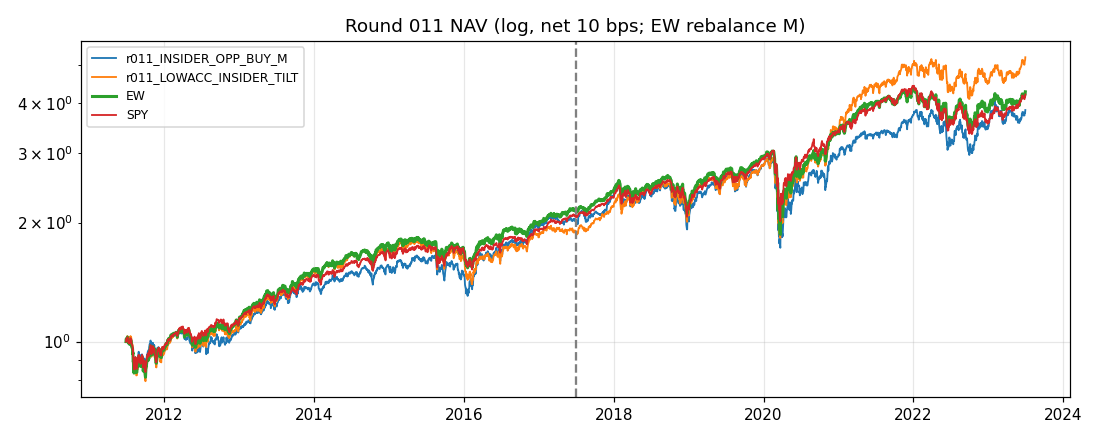

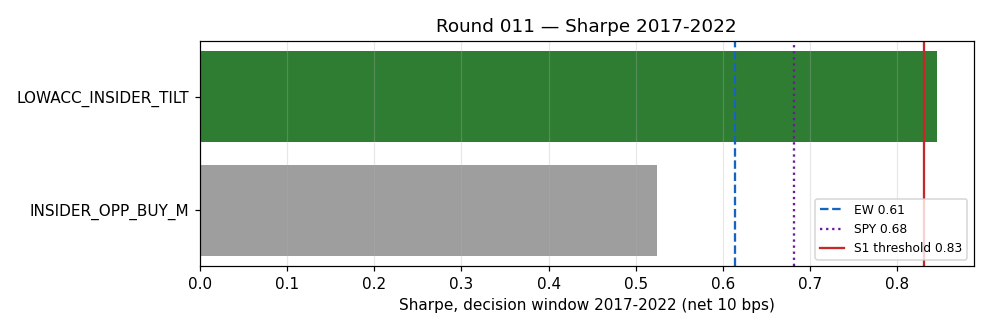

In [2]:
for f in sorted(pathlib.Path("../figures").glob("round_011_*.png")): display(Image(filename=str(f)))

In [3]:
display(Markdown(pathlib.Path("../rounds/round_011/RESULTS.md").read_text()))

# Round 011 — EXPLORE2 T3: opportunistic insider buying — **ไม่มีผู้เข้ารอบ; สัญญาณเดี่ยว "ใช้กับ S&P 500 ไม่ได้"**

ข้อมูล: SEC Insider Transactions Data Sets 2006Q1–2023Q2, 1,711,391 รายการ non-derivative ของบริษัท S&P 500; insider-year ที่จัดกลุ่มได้ 31,760 (opportunistic 69.0%)
ข้อจำกัด: ไม่มีธง 10b5-1 ก่อน 2023 → ตัดรายการตามแผนล่วงหน้าไม่ได้

## จำนวนหุ้นที่มีสัญญาณ (opportunistic P ใน 6 เดือน) ต่อเดือน
เดือนที่ < 20 ตัว: **72.2%** (median 16, min 6, max 39) → ตามเกณฑ์ EXPLORE2: **ใช้เป็นสัญญาณเดี่ยวกับ S&P 500 ไม่ได้**
| ปี | median | min | max |
|---|---|---|---|
| 2011 | 12 | 11 | 15 |
| 2012 | 9 | 6 | 15 |
| 2013 | 12 | 6 | 16 |
| 2014 | 14 | 10 | 16 |
| 2015 | 15 | 8 | 26 |
| 2016 | 19 | 16 | 24 |
| 2017 | 13 | 10 | 22 |
| 2018 | 15 | 7 | 22 |
| 2019 | 24 | 20 | 29 |
| 2020 | 28 | 13 | 39 |
| 2021 | 18 | 13 | 22 |
| 2022 | 18 | 15 | 22 |
| 2023 | 19 | 18 | 20 |

## ผล (2 trial → สะสม 123)
| trial | Sharpe | EW | CAGR (EW) | MaxDD (EW) | S1 | S2 | DSR | S6 เฉลี่ย/ต่ำสุด | ช่วง 2011–16 (EW) | หมายเหตุ |
|---|---|---|---|---|---|---|---|---|---|---|
| `r011_INSIDER_OPP_BUY_M` | 0.524 | 0.614 | 11.3% (12.2%) | -40.6% (-38.4%) | False | 11% | 0.003 | 16.7/6 | 0.890 (1.093) | months with <20 names: 72.2% |
| `r011_LOWACC_INSIDER_TILT` | 0.845 | 0.640 | 18.5% (12.5%) | -37.3% (-37.6%) | True | 100% | 0.471 | 63.2/51 | 0.806 (1.137) | tilted names per rebalance: 3.3 |

- tilt บน low accruals: มีหุ้นที่ได้น้ำหนัก 2 เท่าเฉลี่ยแค่ 3.3 ตัวต่อรอบ → ผลแทบเท่าตัวฐาน `r001_Q_LOWACC_overall` (0.863); ผ่าน S1/S2 แต่ DSR 0.471 < 0.95
